In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Cleaned-Data.csv')

imputer = SimpleImputer(strategy='mean')
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [3]:
df.head()

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,...,Gender_Female,Gender_Male,Gender_Transgender,Severity_Mild,Severity_Moderate,Severity_None,Severity_Severe,Contact_Dont-Know,Contact_No,Contact_Yes
0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Fever                    316800 non-null  float64
 1   Tiredness                316800 non-null  float64
 2   Dry-Cough                316800 non-null  float64
 3   Difficulty-in-Breathing  316800 non-null  float64
 4   Sore-Throat              316800 non-null  float64
 5   None_Sympton             316800 non-null  float64
 6   Pains                    316800 non-null  float64
 7   Nasal-Congestion         316800 non-null  float64
 8   Runny-Nose               316800 non-null  float64
 9   Diarrhea                 316800 non-null  float64
 10  None_Experiencing        316800 non-null  float64
 11  Age_0-9                  316800 non-null  float64
 12  Age_10-19                316800 non-null  float64
 13  Age_20-24                316800 non-null  float64
 14  Age_

In [6]:
df['target'] = df['Severity_Mild'] + df['Severity_Moderate'] + df['Severity_Severe']
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

df = df.drop(columns=['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe', ])

In [7]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7513099747474747
R²: -0.33100854988131
MAE: 0.24869002525252526
MSE: 0.24869002525252526


In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
          

Decision Tree Accuracy: 0.7513099747474747
Confusion Matrix:
 [[    0 15757]
 [    0 47603]]
Precision: 0.7513099747474747
Recall: 1.0
F1 Score: 0.8579977109486946


--- Logistic Regression ---
Accuracy: 0.7513099747474747
Confusion Matrix:
 [[    0 15757]
 [    0 47603]]
Precision: 0.7513099747474747
Recall: 1.0
F1 Score: 0.8579977109486946
--- Decision Tree ---
Accuracy: 0.7513099747474747
Confusion Matrix:
 [[    0 15757]
 [    0 47603]]
Precision: 0.7513099747474747
Recall: 1.0
F1 Score: 0.8579977109486946
Logistic Regression ROC AUC: 0.4888558457083201


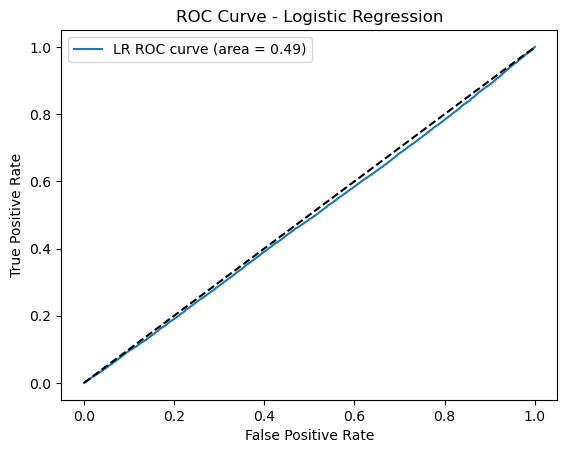

In [11]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

models = {'Logistic Regression': (y_test, y_pred_lr),
          'Decision Tree': (y_test, y_pred_dt),
          #'SVM': (y_test, y_pred_svm)}
         }
for name, (true, pred) in models.items():
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(true, pred))
    print("Confusion Matrix:\n", confusion_matrix(true, pred))
    print("Precision:", precision_score(true, pred))
    print("Recall:", recall_score(true, pred))
    print("F1 Score:", f1_score(true, pred))
    
# For ROC/AUC curve, example on Logistic Regression:
y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression ROC AUC: {auc}")

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label=f'LR ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()